In [1]:
# ============================================================
# PROJET 1 — ANALYSE DES VENTES RETAIL
# ============================================================
# Dataset  : UCI Online Retail (541 909 transactions)
# Période  : 01/12/2010 → 09/12/2011
# Source   : https://archive.ics.uci.edu/dataset/352/online+retail
# Outils   : Pandas · Matplotlib · Seaborn
# Objectif : EDA complète + rapport visuel d'un e-commerce UK
# ============================================================

## Projet 1 — Analyse des Ventes Retail 

**Dataset :** UCI Online Retail  
**Période :** Décembre 2010 – Décembre 2011  
**Outils :** Python · Pandas · Matplotlib · Seaborn  

---

## Questions analytiques

1. Quels sont les produits les plus vendus ?
2. Quels pays génèrent le plus de revenus ?
3. Comment évoluent les ventes dans le temps ?
4. Quel est le profil des meilleurs clients ?
5. Y a-t-il des tendances saisonnières ?

In [2]:
# ============================================================
# ÉTAPE 1 — IMPORTS & CONFIGURATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# Suppression des warnings non critiques
warnings.filterwarnings('ignore')

# Style global des graphiques
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Imports OK !")

✅ Imports OK !


In [17]:
# ============================================================
# ÉTAPE 2 — CHARGEMENT & PREMIÈRE INSPECTION
# ============================================================

# Remplace le chemin par l'emplacement de ton fichier
df = pd.read_excel('data/Online Retail.xlsx', engine='openpyxl')

# --- Structure générale ---
print(f" Dataset chargé !")
print(f"\n Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"\n Colonnes et types :")
print(df.dtypes)
print(f"\n Aperçu des 5 premières lignes :")
df.head()

✅ Dataset chargé !

📐 Dimensions : 541,909 lignes × 8 colonnes

📋 Colonnes et types :
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

👀 Aperçu des 5 premières lignes :


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [19]:
# ============================================================
# ÉTAPE 3 — VUE GLOBALE DES VALEURS MANQUANTES
# ============================================================

print(" Valeurs manquantes par colonne :\n")

missing = pd.DataFrame({
    'Manquants'  : df.isnull().sum(),
    'Pourcentage': (df.isnull().sum() / len(df) * 100).round(2)
})

# On n'affiche que les colonnes qui ont des manquants
print(missing[missing['Manquants'] > 0])

print(f"\n Colonnes sans valeurs manquantes : {(missing['Manquants'] == 0).sum()}/8")

 Valeurs manquantes par colonne :

             Manquants  Pourcentage
Description       1454         0.27
CustomerID      135080        24.93

 Colonnes sans valeurs manquantes : 6/8


In [18]:
# ============================================================
# ÉTAPE 4 — DÉTECTION DES ANOMALIES
# ============================================================

# Quantités négatives = retours / annulations
nb_negatifs = (df['Quantity'] < 0).sum()
print(f" Transactions avec Quantity négative : {nb_negatifs:,}")

# Prix à zéro = produits offerts ou erreurs de saisie
nb_zero_price = (df['UnitPrice'] <= 0).sum()
print(f" Transactions avec UnitPrice ≤ 0 : {nb_zero_price:,}")

# InvoiceNo commençant par 'C' = commandes annulées (convention du dataset)
nb_annulations = df['InvoiceNo'].astype(str).str.startswith('C').sum()
print(f" Commandes annulées (InvoiceNo starts with 'C') : {nb_annulations:,}")

print(f"\n Dataset original : {len(df):,} lignes")
print(f" Lignes problématiques détectées : {nb_negatifs + nb_zero_price:,}")

 Transactions avec Quantity négative : 10,624
 Transactions avec UnitPrice ≤ 0 : 2,517
 Commandes annulées (InvoiceNo starts with 'C') : 9,288

 Dataset original : 541,909 lignes
 Lignes problématiques détectées : 13,141


In [20]:
# ============================================================
# ÉTAPE 5 — DATA CLEANING
# ============================================================

print(f" Avant nettoyage : {len(df):,} lignes\n")

# 1. Supprimer les quantités négatives (retours)
df = df[df['Quantity'] > 0]
print(f" Après suppression Quantity ≤ 0 : {len(df):,} lignes")

# 2. Supprimer les prix invalides
df = df[df['UnitPrice'] > 0]
print(f" Après suppression UnitPrice ≤ 0 : {len(df):,} lignes")

# 3. Supprimer les commandes annulées
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f" Après suppression annulations   : {len(df):,} lignes")

# 4. Supprimer les descriptions manquantes
df = df.dropna(subset=['Description'])
print(f" Après suppression Description NaN : {len(df):,} lignes")

# 5. Créer la colonne Revenue = Quantity × UnitPrice
df['Revenue'] = df['Quantity'] * df['UnitPrice']
print(f"\n Colonne Revenue créée ✅")

print(f"\n Après nettoyage : {len(df):,} lignes")
print(f" Lignes supprimées : {541_909 - len(df):,} ({(541_909 - len(df))/541_909*100:.1f}%)")

 Avant nettoyage : 541,909 lignes

 Après suppression Quantity ≤ 0 : 531,285 lignes
 Après suppression UnitPrice ≤ 0 : 530,104 lignes
 Après suppression annulations   : 530,104 lignes
 Après suppression Description NaN : 530,104 lignes

 Colonne Revenue créée ✅

 Après nettoyage : 530,104 lignes
 Lignes supprimées : 11,805 (2.2%)


In [7]:
# ============================================================
# ÉTAPE 6 — STATISTIQUES DESCRIPTIVES
# ============================================================

# --- Vue globale des métriques clés ---
revenu_total = df['Revenue'].sum()
nb_commandes = df['InvoiceNo'].nunique()
nb_clients   = df['CustomerID'].nunique()
nb_produits  = df['StockCode'].nunique()
nb_pays      = df['Country'].nunique()

print("=" * 45)
print("        TABLEAU DE BORD GLOBAL")
print("=" * 45)
print(f" Revenu total       : £{revenu_total:>12,.2f}")
print(f" Nb de commandes    : {nb_commandes:>12,}")
print(f" Nb de clients      : {nb_clients:>12,}")
print(f" Nb de produits     : {nb_produits:>12,}")
print(f" Nb de pays         : {nb_pays:>12,}")
print("=" * 45)

# --- Statistiques par transaction ---
print("\n Statistiques par transaction :\n")
print(df[['Quantity', 'UnitPrice', 'Revenue']].describe().round(2))

        TABLEAU DE BORD GLOBAL
💰 Revenu total       : £10,666,684.54
🧾 Nb de commandes    :       19,960
👥 Nb de clients      :        4,338
📦 Nb de produits     :        3,922
🌍 Nb de pays         :           38

📊 Statistiques par transaction :

        Quantity  UnitPrice    Revenue
count  530104.00  530104.00  530104.00
mean       10.54       3.91      20.12
std       155.52      35.92     270.36
min         1.00       0.00       0.00
25%         1.00       1.25       3.75
50%         3.00       2.08       9.90
75%        10.00       4.13      17.70
max     80995.00   13541.33  168469.60


In [8]:
# ============================================================
# ÉTAPE 7 — ANALYSE GROUPBY
# ============================================================

# --- Top 10 pays par revenu ---
top_pays = (df.groupby('Country')['Revenue']
              .sum()
              .sort_values(ascending=False)
              .head(10)
              .reset_index())

top_pays.columns = ['Pays', 'Revenu']
top_pays['Revenu_pct'] = (top_pays['Revenu'] / top_pays['Revenu'].sum() * 100).round(1)

print(" Top 10 pays par revenu :\n")
print(top_pays.to_string(index=False))

# --- Top 10 produits par revenu ---
top_produits = (df.groupby('Description')['Revenue']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10)
                  .reset_index())

top_produits.columns = ['Produit', 'Revenu']

print("\n\n Top 10 produits par revenu :\n")
print(top_produits.to_string(index=False))

# --- Top 10 clients par revenu ---
top_clients = (df.dropna(subset=['CustomerID'])
                 .groupby('CustomerID')['Revenue']
                 .sum()
                 .sort_values(ascending=False)
                 .head(10)
                 .reset_index())

top_clients.columns = ['CustomerID', 'Revenu']

print("\n\n Top 10 clients par revenu :\n")
print(top_clients.to_string(index=False))

🌍 Top 10 pays par revenu :

          Pays      Revenu  Revenu_pct
United Kingdom 9025222.084        87.0
   Netherlands  285446.340         2.8
          EIRE  283453.960         2.7
       Germany  228867.140         2.2
        France  209715.110         2.0
     Australia  138521.310         1.3
         Spain   61577.110         0.6
   Switzerland   57089.900         0.6
       Belgium   41196.340         0.4
        Sweden   38378.330         0.4


📦 Top 10 produits par revenu :

                           Produit    Revenu
                    DOTCOM POSTAGE 206248.77
          REGENCY CAKESTAND 3 TIER 174484.74
       PAPER CRAFT , LITTLE BIRDIE 168469.60
WHITE HANGING HEART T-LIGHT HOLDER 106292.77
                     PARTY BUNTING  99504.33
           JUMBO BAG RED RETROSPOT  94340.05
    MEDIUM CERAMIC TOP STORAGE JAR  81700.92
                            Manual  78112.82
                           POSTAGE  78101.88
                RABBIT NIGHT LIGHT  66964.99


👥 Top 10 cli

In [9]:
# ============================================================
# ÉTAPE 8 — NETTOYAGE PRODUITS + PIVOT TABLE
# ============================================================

# Filtrer les entrées non-produits
mots_exclus = ['POSTAGE', 'DOTCOM POSTAGE', 'Manual', 
               'AMAZONFEE', 'Bank Charges', 'CRUK']

df_produits = df[~df['Description'].isin(mots_exclus)]

# --- Pivot Table : Revenu par pays et par mois ---
# On extrait le mois depuis InvoiceDate
df_produits['Mois'] = df_produits['InvoiceDate'].dt.to_period('M')

pivot = df_produits.pivot_table(
    values='Revenue',
    index='Country',
    columns='Mois',
    aggfunc='sum',
    fill_value=0
)

# On garde uniquement le Top 5 pays pour la lisibilité
top5_pays = top_pays['Pays'].head(5).tolist()
pivot_top5 = pivot.loc[pivot.index.isin(top5_pays)]

print(" Pivot Table — Revenu mensuel par pays (Top 5) :\n")
print(pivot_top5.to_string())

📊 Pivot Table — Revenu mensuel par pays (Top 5) :

Mois              2010-12    2011-01    2011-02    2011-03     2011-04    2011-05    2011-06     2011-07    2011-08     2011-09    2011-10     2011-11    2011-12
Country                                                                                                                                                          
EIRE             10033.26   21904.19   12248.74   18823.17    7570.500   18008.76   21188.29   42789.850   18353.75   43086.550   24317.92    30738.43    7340.89
France            8680.31   16174.12    7687.96   13689.55    3899.310   16210.88   14962.41    9171.190   12630.96   21898.040   24008.33    29216.76    6538.92
Germany          13279.14   15326.84    8825.05   12862.69   10994.790   23518.20   12122.10   14743.300   17636.77   16561.220   28422.92    24252.70    7024.17
Netherlands       8754.48   26596.16   22831.91   22206.49    2886.560   28942.88   26753.09      11.020   40327.81   26832.260   40378.65 

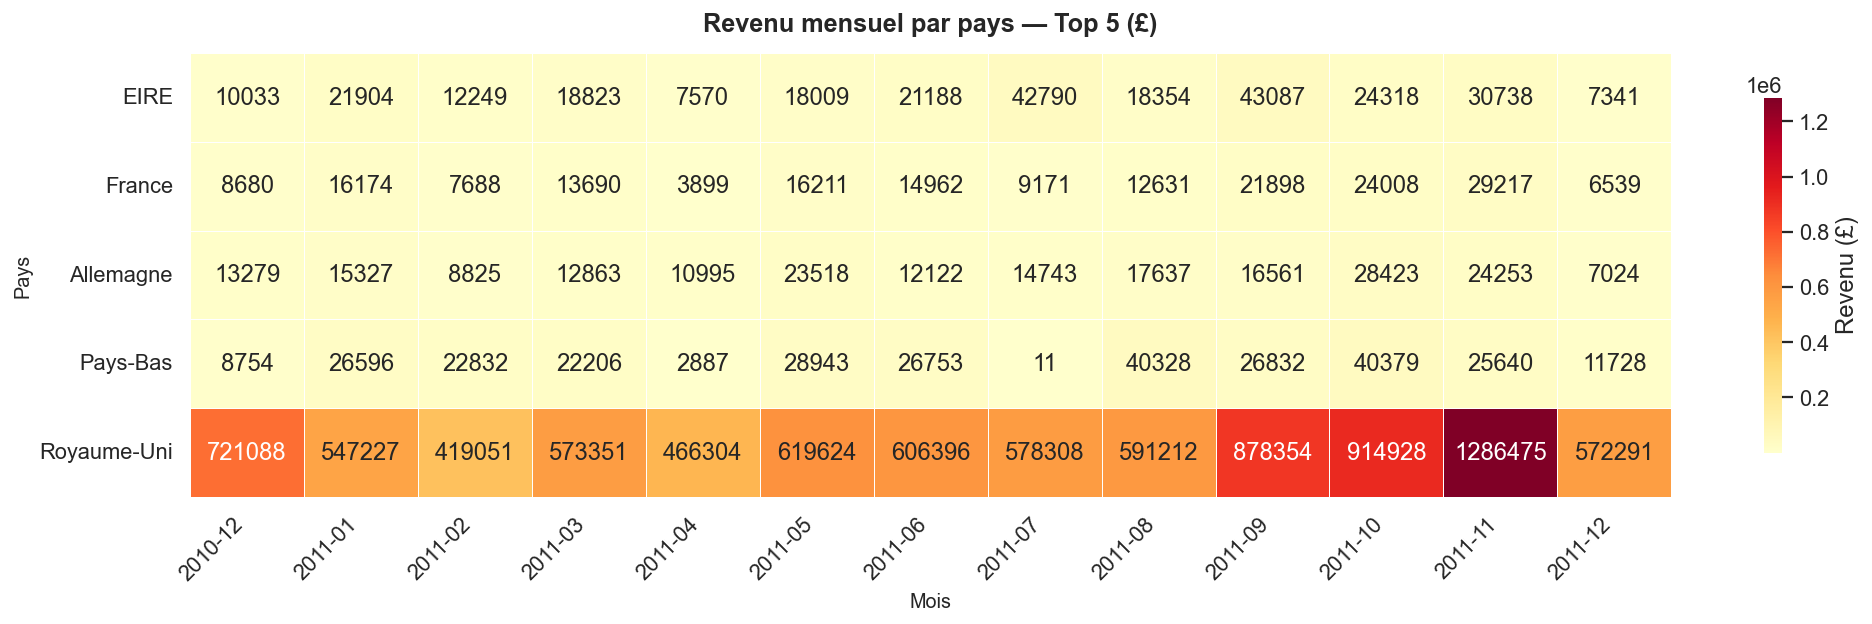

In [10]:
# ============================================================
# ÉTAPE 9 — HEATMAP PIVOT TABLE
# ============================================================

import matplotlib.ticker as mticker

# Convertir les colonnes Period en string pour l'affichage
pivot_plot = pivot_top5.copy()
pivot_plot.columns = [str(c) for c in pivot_plot.columns]

# Raccourcir les noms de pays pour l'affichage
pivot_plot.index = ['EIRE', 'France', 'Allemagne', 
                    'Pays-Bas', 'Royaume-Uni']

fig, ax = plt.subplots(figsize=(16, 5))

sns.heatmap(
    pivot_plot,
    ax=ax,
    cmap='YlOrRd',        # Jaune = faible, Rouge = élevé
    fmt='.0f',
    annot=True,           # Affiche les valeurs dans chaque cellule
    linewidths=0.5,
    cbar_kws={
        'label': 'Revenu (£)',
        'shrink': 0.8
    }
)

ax.set_title('Revenu mensuel par pays — Top 5 (£)', 
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Mois', fontsize=11)
ax.set_ylabel('Pays', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

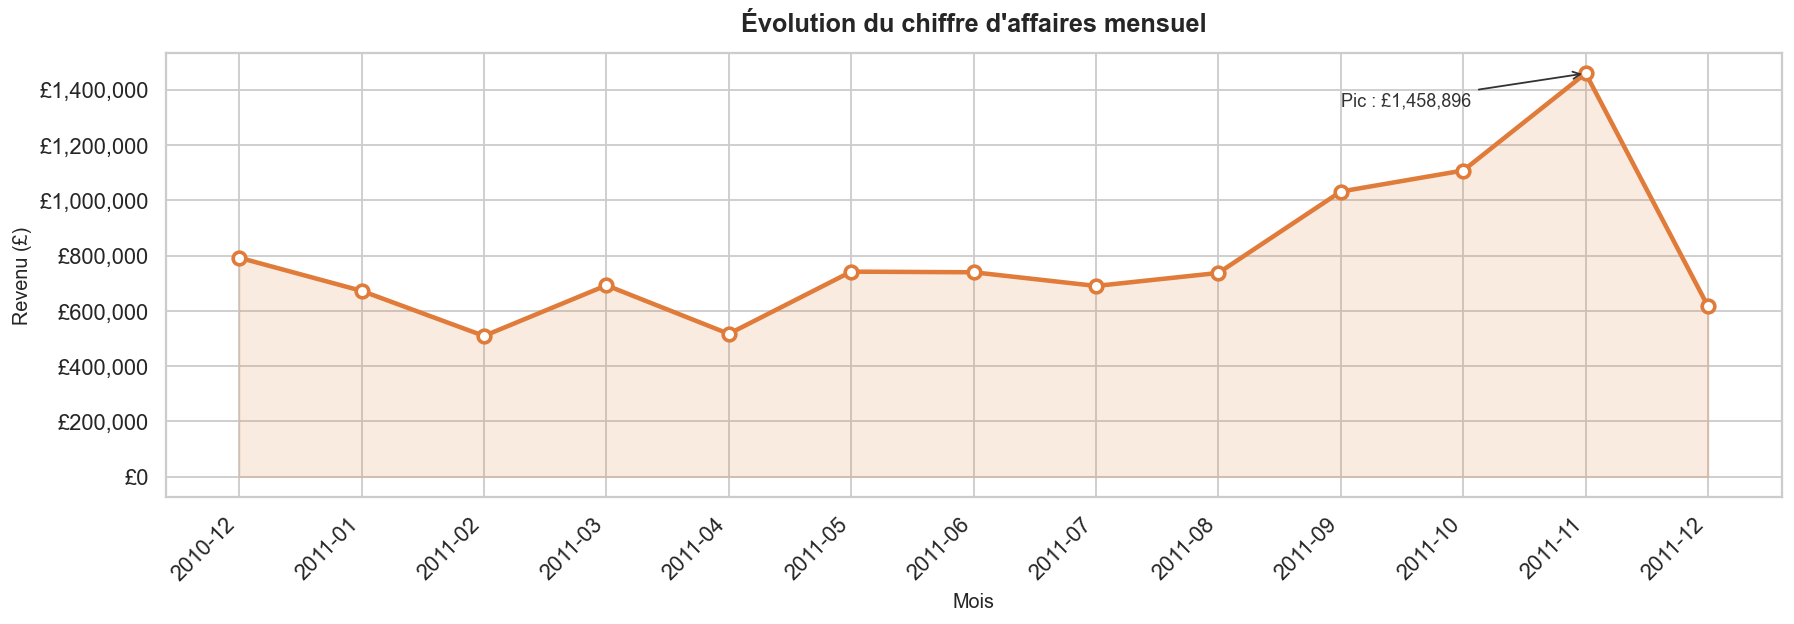

In [11]:
# ============================================================
# ÉTAPE 10 — VISUALISATION 1 : ÉVOLUTION DU CA DANS LE TEMPS
# ============================================================

# Agréger le revenu par mois
ca_mensuel = (df_produits.groupby(
                df_produits['InvoiceDate'].dt.to_period('M'))['Revenue']
                .sum()
                .reset_index())

ca_mensuel.columns = ['Mois', 'Revenu']
ca_mensuel['Mois'] = ca_mensuel['Mois'].astype(str)

# --- Graphique ---
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(ca_mensuel['Mois'], ca_mensuel['Revenu'],
        color='#E07B39', linewidth=2.5, marker='o',
        markersize=7, markerfacecolor='white',
        markeredgewidth=2, markeredgecolor='#E07B39')

# Remplissage sous la courbe
ax.fill_between(ca_mensuel['Mois'], ca_mensuel['Revenu'],
                alpha=0.15, color='#E07B39')

# Annotation du pic
idx_max = ca_mensuel['Revenu'].idxmax()
ax.annotate(f"Pic : £{ca_mensuel.loc[idx_max, 'Revenu']:,.0f}",
            xy=(ca_mensuel.loc[idx_max, 'Mois'], 
                ca_mensuel.loc[idx_max, 'Revenu']),
            xytext=(idx_max - 2, ca_mensuel.loc[idx_max, 'Revenu'] * 0.92),
            arrowprops=dict(arrowstyle='->', color='#333'),
            fontsize=10, color='#333')

ax.set_title("Évolution du chiffre d'affaires mensuel",
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Mois', fontsize=11)
ax.set_ylabel('Revenu (£)', fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

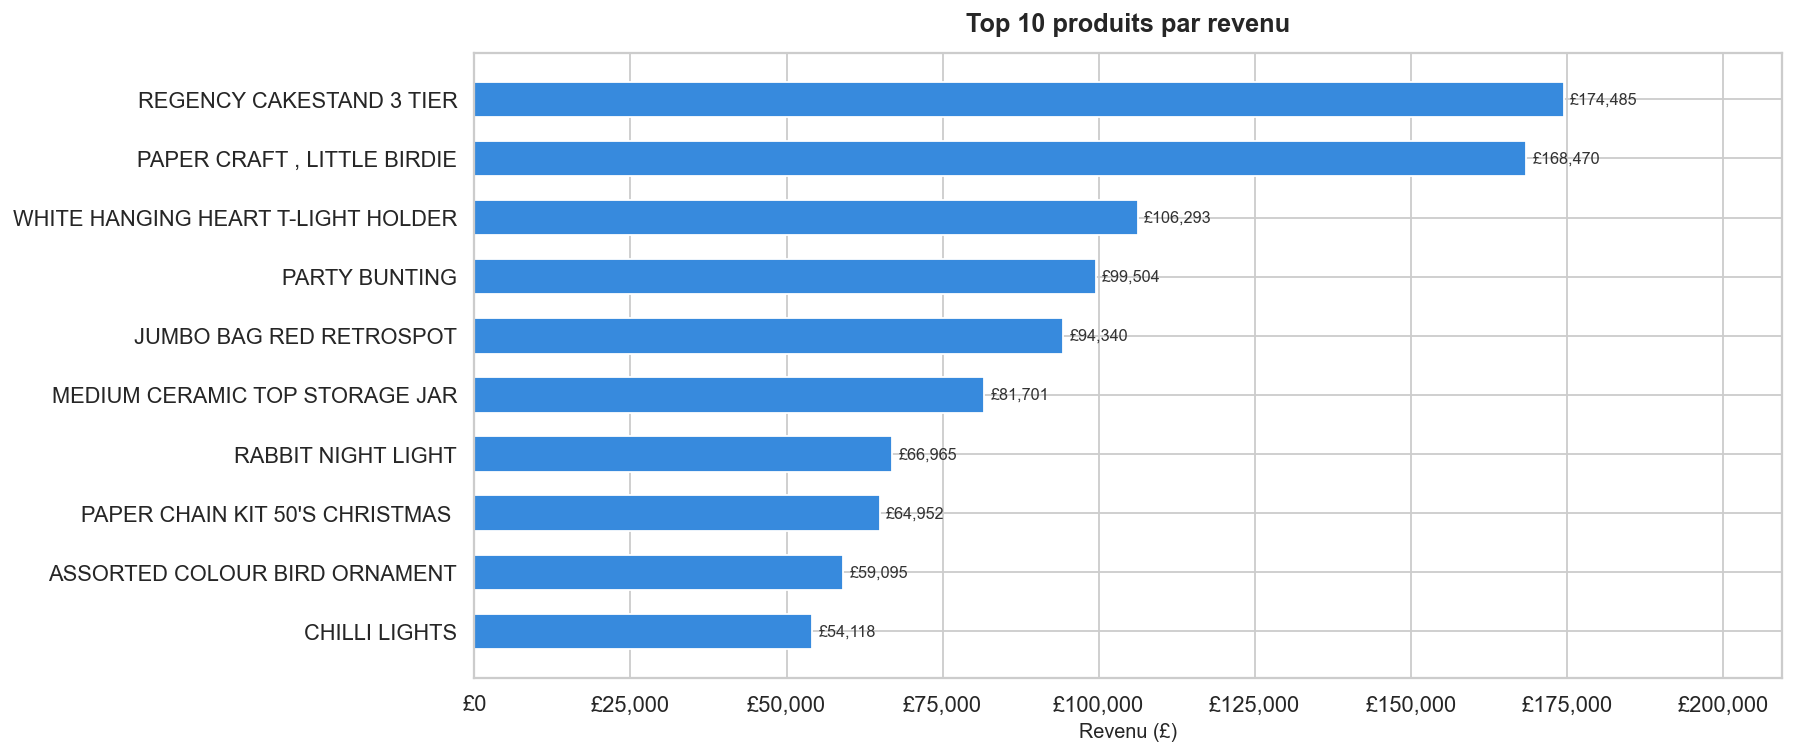

In [12]:
# ============================================================
# ÉTAPE 11 — VISUALISATION 2 : TOP 10 PRODUITS PAR REVENU
# ============================================================

top10_produits = (df_produits.groupby('Description')['Revenue']
                             .sum()
                             .sort_values(ascending=False)
                             .head(10)
                             .reset_index())

top10_produits.columns = ['Produit', 'Revenu']

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(top10_produits['Produit'][::-1],
               top10_produits['Revenu'][::-1],
               color='#378ADD', edgecolor='white',
               height=0.6)

# Annotations des valeurs sur chaque barre
for bar, val in zip(bars, top10_produits['Revenu'][::-1]):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=9, color='#333')

ax.set_title('Top 10 produits par revenu',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Revenu (£)', fontsize=11)
ax.set_ylabel('')
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.set_xlim(0, top10_produits['Revenu'].max() * 1.2)
plt.tight_layout()
plt.show()

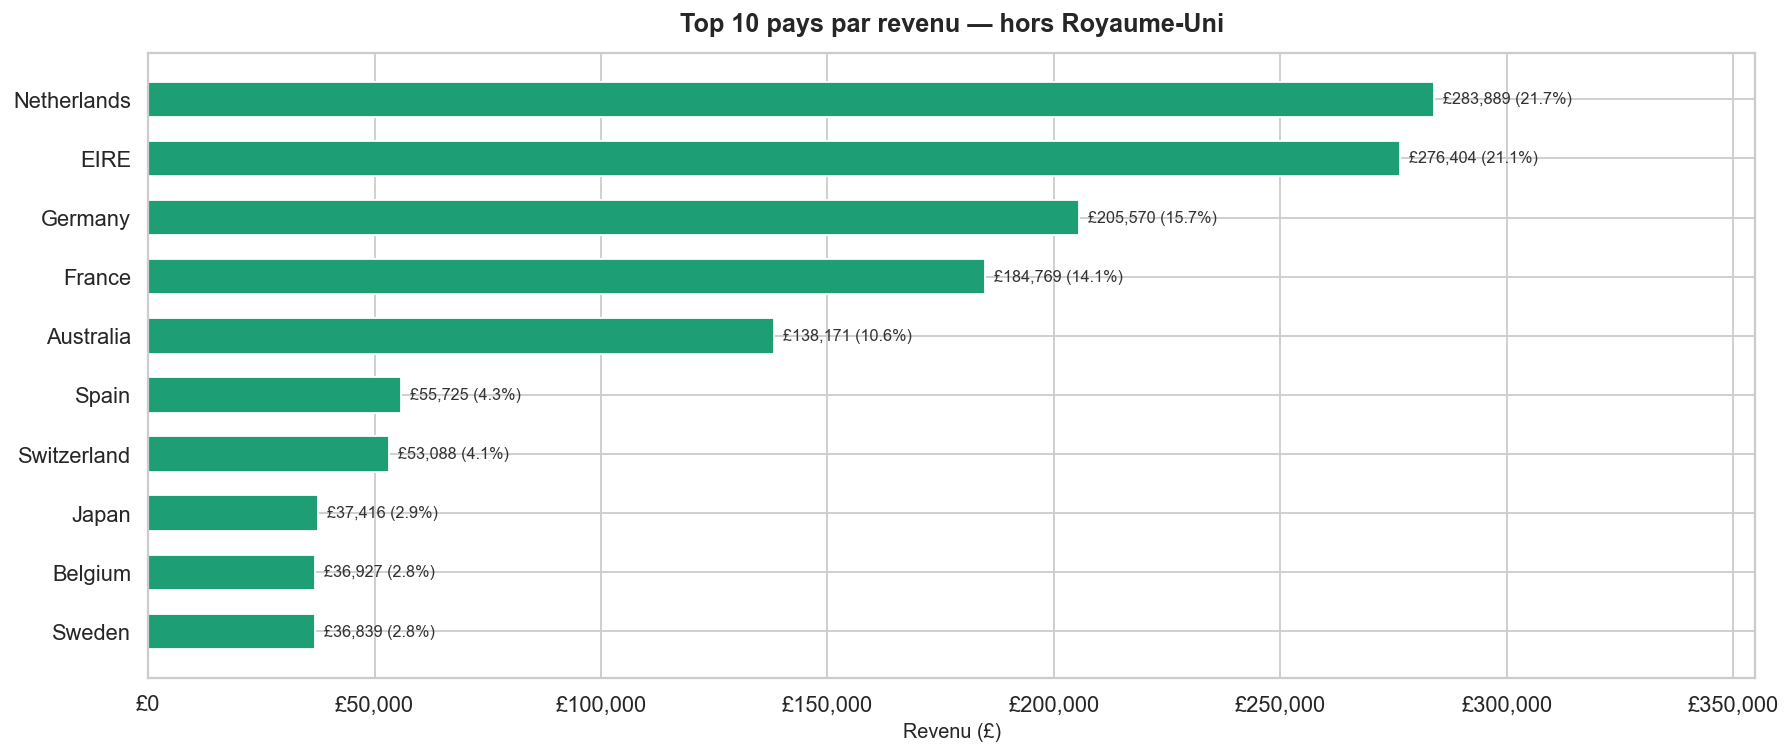

In [13]:
# ============================================================
# ÉTAPE 12 — VISUALISATION 3 : REVENUS PAR PAYS (SANS UK)
# ============================================================

# Exclure le UK pour mieux voir les autres marchés
df_hors_uk = df_produits[df_produits['Country'] != 'United Kingdom']

top10_pays = (df_hors_uk.groupby('Country')['Revenue']
                        .sum()
                        .sort_values(ascending=False)
                        .head(10)
                        .reset_index())

top10_pays.columns = ['Pays', 'Revenu']
top10_pays['Pct'] = (top10_pays['Revenu'] / 
                     top10_pays['Revenu'].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(top10_pays['Pays'][::-1],
               top10_pays['Revenu'][::-1],
               color='#1D9E75', edgecolor='white',
               height=0.6)

for bar, (val, pct) in zip(bars, 
    zip(top10_pays['Revenu'][::-1], top10_pays['Pct'][::-1])):
    ax.text(bar.get_width() + 2000,
            bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f} ({pct}%)',
            va='center', fontsize=9, color='#333')

ax.set_title('Top 10 pays par revenu — hors Royaume-Uni',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Revenu (£)', fontsize=11)
ax.set_ylabel('')
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.set_xlim(0, top10_pays['Revenu'].max() * 1.25)
plt.tight_layout()
plt.show()

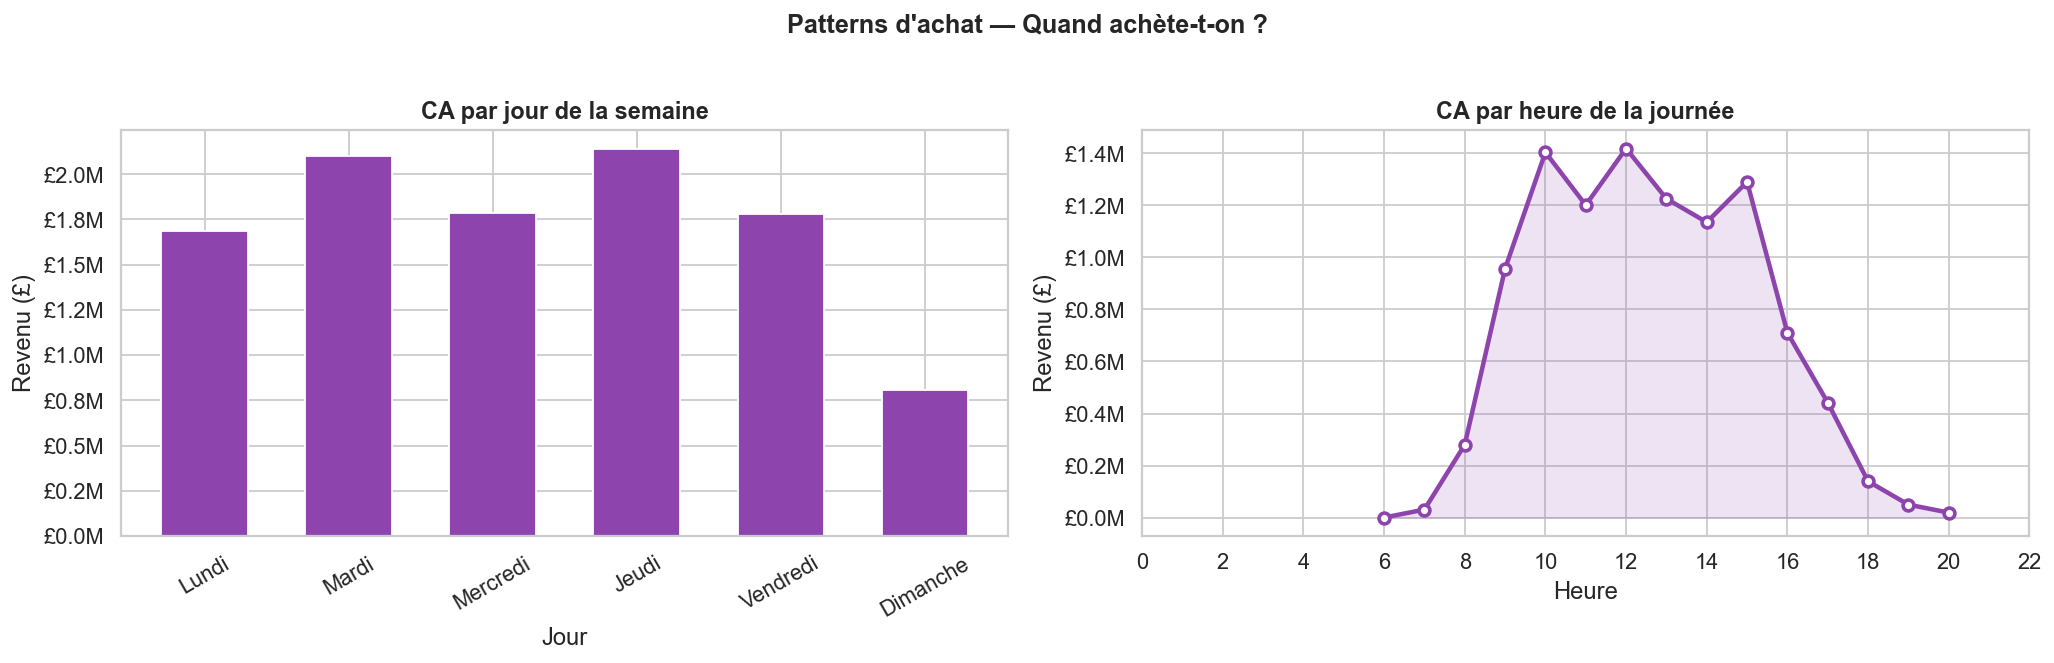

In [14]:
# ============================================================
# ÉTAPE 13 — VISUALISATION 4 : PATTERNS D'ACHAT
# ============================================================

# Extraire le jour de la semaine et l'heure
df_produits['JourSemaine'] = df_produits['InvoiceDate'].dt.dayofweek
df_produits['Heure'] = df_produits['InvoiceDate'].dt.hour

jours_labels = ['Lundi', 'Mardi', 'Mercredi', 
                'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']

# Revenu par jour de la semaine
ca_jour = (df_produits.groupby('JourSemaine')['Revenue']
                      .sum()
                      .reset_index())
ca_jour['Jour'] = ca_jour['JourSemaine'].map(
                  dict(enumerate(jours_labels)))

# Revenu par heure
ca_heure = (df_produits.groupby('Heure')['Revenue']
                       .sum()
                       .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Graphique 1 : Par jour ---
axes[0].bar(ca_jour['Jour'], ca_jour['Revenue'],
            color='#8E44AD', edgecolor='white', width=0.6)
axes[0].set_title('CA par jour de la semaine',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jour')
axes[0].set_ylabel('Revenu (£)')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=30)

# --- Graphique 2 : Par heure ---
axes[1].plot(ca_heure['Heure'], ca_heure['Revenue'],
             color='#8E44AD', linewidth=2.5,
             marker='o', markersize=6,
             markerfacecolor='white', markeredgewidth=2,
             markeredgecolor='#8E44AD')
axes[1].fill_between(ca_heure['Heure'], ca_heure['Revenue'],
                     alpha=0.15, color='#8E44AD')
axes[1].set_title("CA par heure de la journée",
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Heure')
axes[1].set_ylabel('Revenu (£)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
axes[1].set_xticks(range(0, 24, 2))

plt.suptitle("Patterns d'achat — Quand achète-t-on ?",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

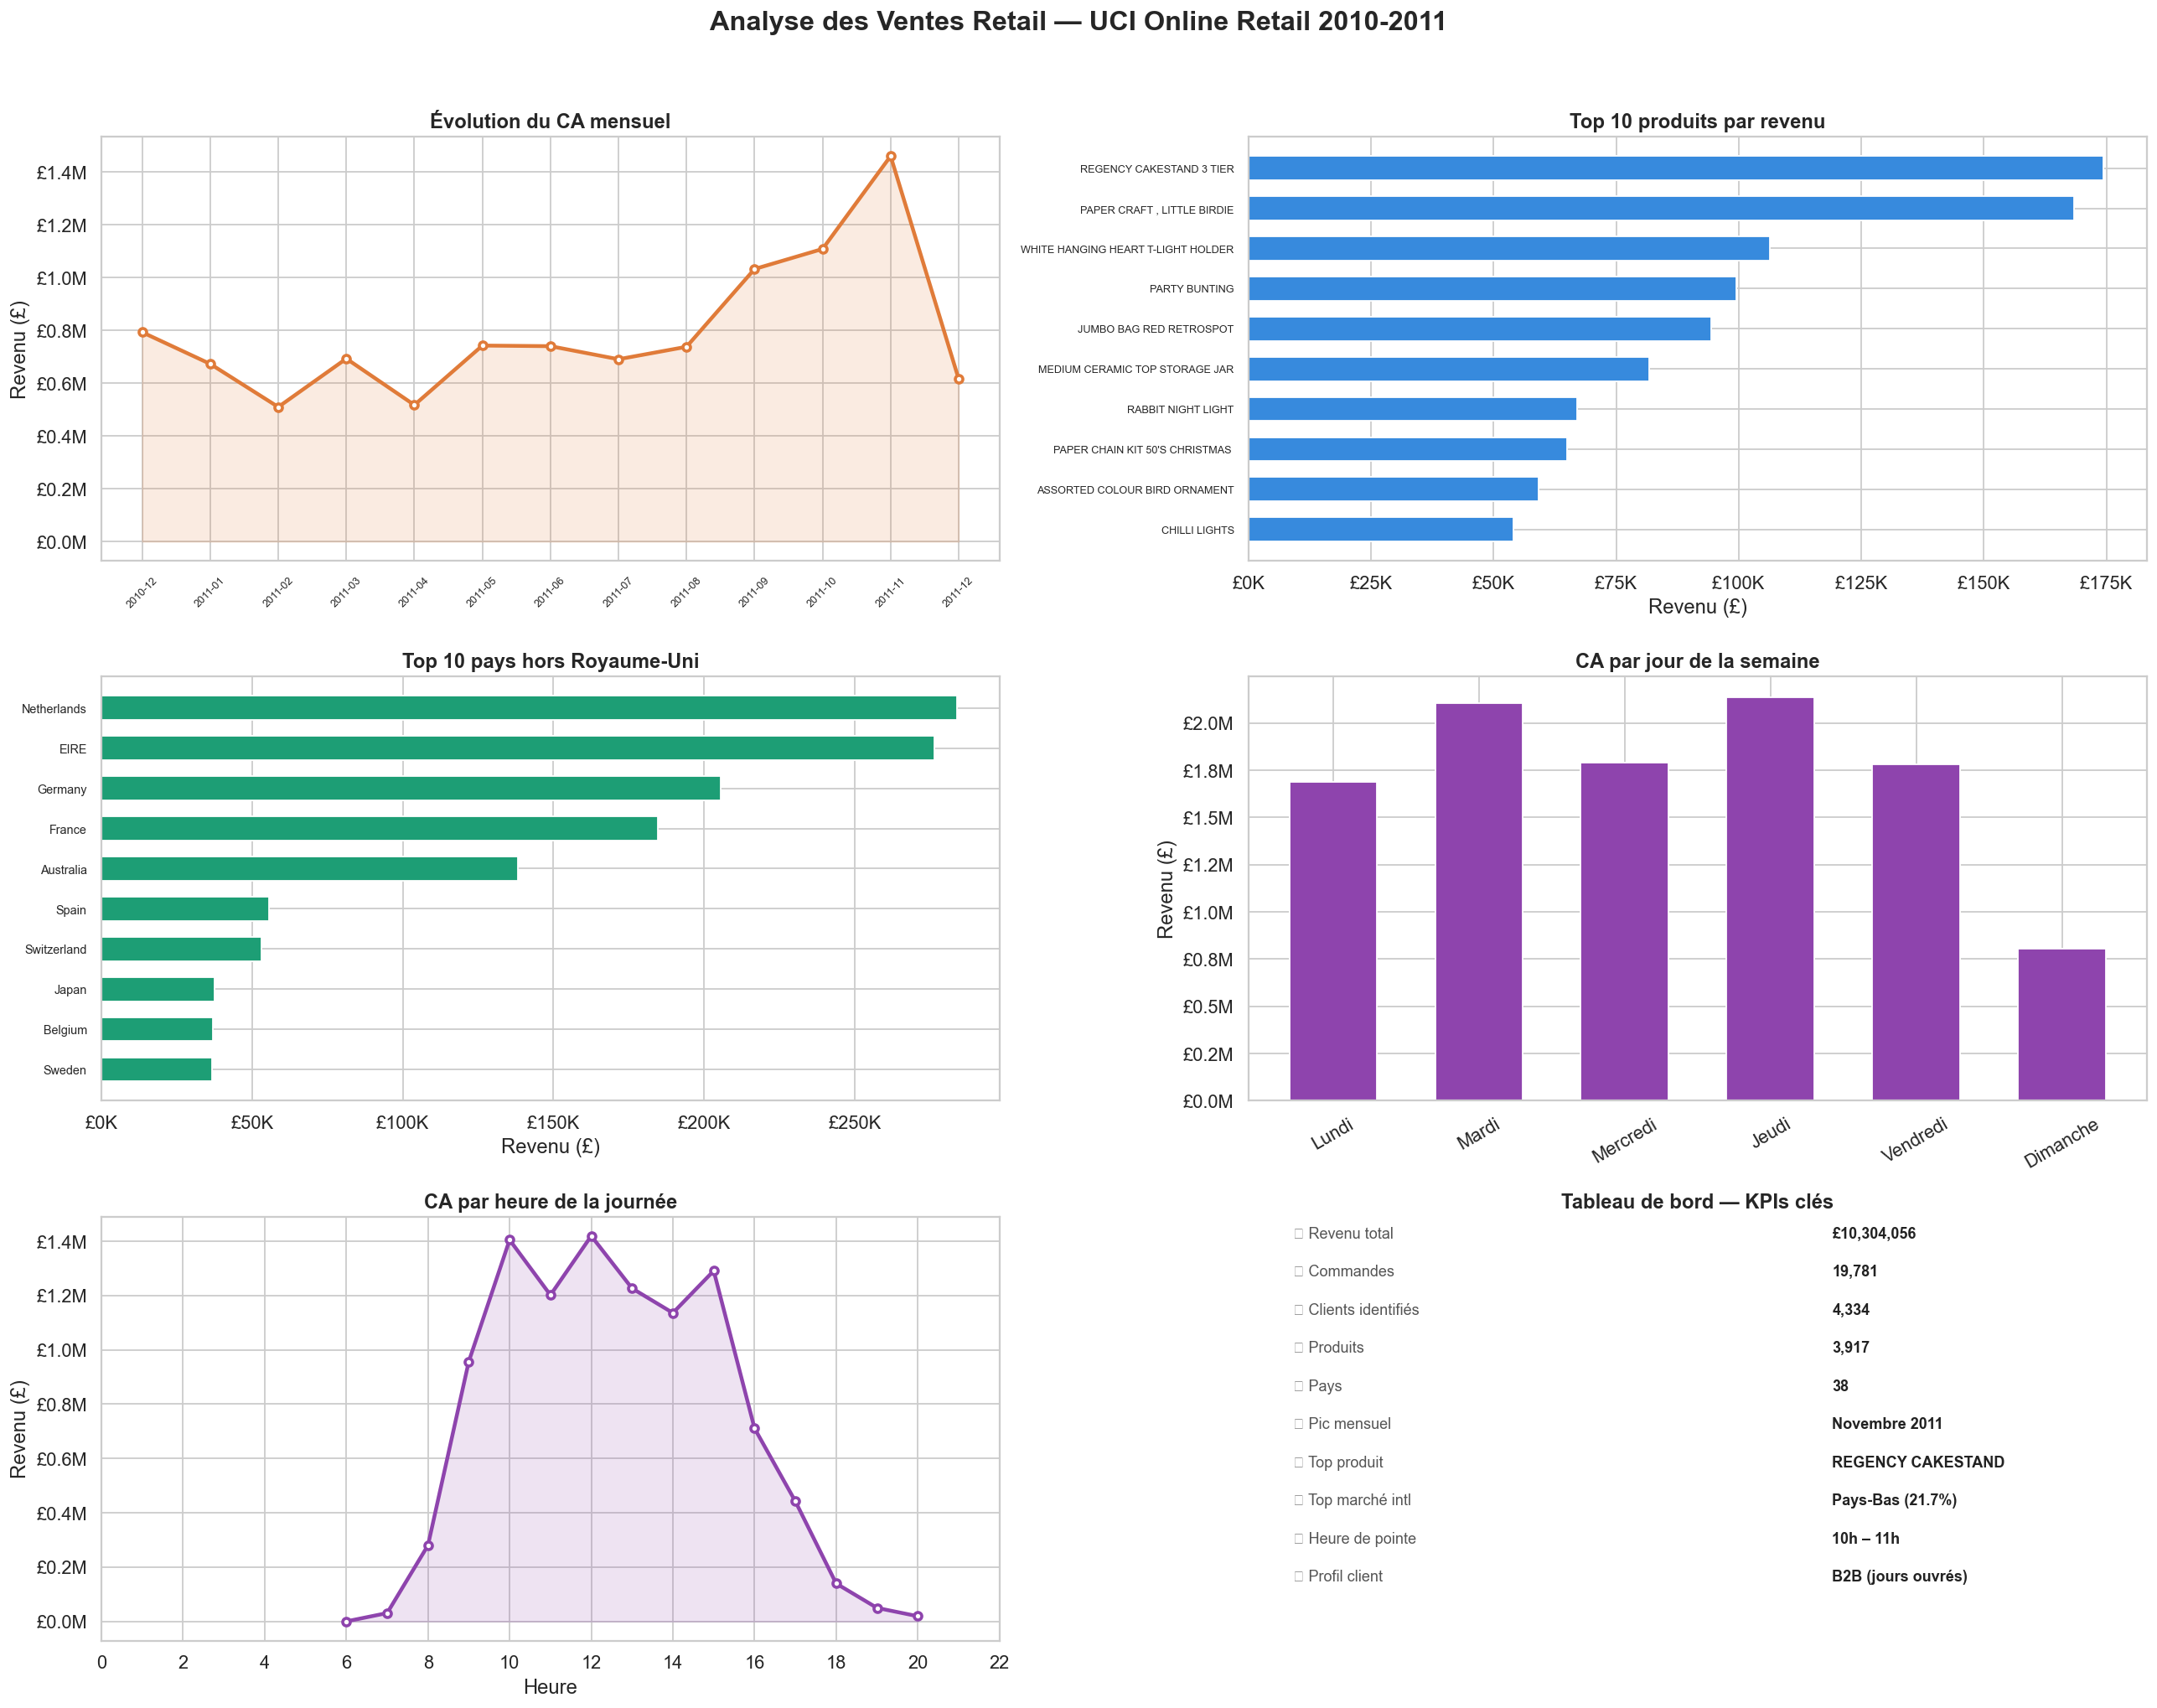


✅ Rapport sauvegardé : rapport_visuel_retail.png


In [15]:
# ============================================================
# ÉTAPE 14 — RAPPORT VISUEL FINAL
# ============================================================

fig = plt.figure(figsize=(20, 16))
fig.suptitle("Analyse des Ventes Retail — UCI Online Retail 2010-2011",
             fontsize=18, fontweight='bold', y=0.98)

# --- Couleurs ---
BLEU    = '#378ADD'
VERT    = '#1D9E75'
ORANGE  = '#E07B39'
VIOLET  = '#8E44AD'

# ============================================================
# GRAPHIQUE 1 (haut gauche) : Évolution CA mensuel
# ============================================================
ax1 = fig.add_subplot(3, 2, 1)

ca_mensuel_plot = ca_mensuel.copy()
ax1.plot(ca_mensuel_plot['Mois'], ca_mensuel_plot['Revenu'],
         color=ORANGE, linewidth=2.5, marker='o',
         markersize=5, markerfacecolor='white',
         markeredgewidth=2, markeredgecolor=ORANGE)
ax1.fill_between(ca_mensuel_plot['Mois'],
                 ca_mensuel_plot['Revenu'],
                 alpha=0.15, color=ORANGE)
ax1.set_title("Évolution du CA mensuel", fontweight='bold')
ax1.set_ylabel('Revenu (£)')
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='x', labelsize=7)

# ============================================================
# GRAPHIQUE 2 (haut droite) : Top 10 produits
# ============================================================
ax2 = fig.add_subplot(3, 2, 2)

ax2.barh(top10_produits['Produit'][::-1],
         top10_produits['Revenu'][::-1],
         color=BLEU, edgecolor='white', height=0.6)
ax2.set_title("Top 10 produits par revenu", fontweight='bold')
ax2.set_xlabel('Revenu (£)')
ax2.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
ax2.tick_params(axis='y', labelsize=7)

# ============================================================
# GRAPHIQUE 3 (milieu gauche) : Top pays hors UK
# ============================================================
ax3 = fig.add_subplot(3, 2, 3)

ax3.barh(top10_pays['Pays'][::-1],
         top10_pays['Revenu'][::-1],
         color=VERT, edgecolor='white', height=0.6)
ax3.set_title("Top 10 pays hors Royaume-Uni", fontweight='bold')
ax3.set_xlabel('Revenu (£)')
ax3.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
ax3.tick_params(axis='y', labelsize=8)

# ============================================================
# GRAPHIQUE 4 (milieu droite) : CA par jour
# ============================================================
ax4 = fig.add_subplot(3, 2, 4)

ca_jour_clean = ca_jour.dropna(subset=['Jour'])
ax4.bar(ca_jour_clean['Jour'], ca_jour_clean['Revenue'],
        color=VIOLET, edgecolor='white', width=0.6)
ax4.set_title("CA par jour de la semaine", fontweight='bold')
ax4.set_ylabel('Revenu (£)')
ax4.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
ax4.tick_params(axis='x', rotation=30)

# ============================================================
# GRAPHIQUE 5 (bas gauche) : CA par heure
# ============================================================
ax5 = fig.add_subplot(3, 2, 5)

ax5.plot(ca_heure['Heure'], ca_heure['Revenue'],
         color=VIOLET, linewidth=2.5, marker='o',
         markersize=5, markerfacecolor='white',
         markeredgewidth=2, markeredgecolor=VIOLET)
ax5.fill_between(ca_heure['Heure'], ca_heure['Revenue'],
                 alpha=0.15, color=VIOLET)
ax5.set_title("CA par heure de la journée", fontweight='bold')
ax5.set_xlabel('Heure')
ax5.set_ylabel('Revenu (£)')
ax5.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
ax5.set_xticks(range(0, 24, 2))

# ============================================================
# GRAPHIQUE 6 (bas droite) : KPIs texte
# ============================================================
ax6 = fig.add_subplot(3, 2, 6)
ax6.axis('off')

kpis = [
    (" Revenu total",      f"£{df_produits['Revenue'].sum():,.0f}"),
    (" Commandes",         f"{df_produits['InvoiceNo'].nunique():,}"),
    (" Clients identifiés",f"{df_produits['CustomerID'].nunique():,}"),
    (" Produits",          f"{df_produits['StockCode'].nunique():,}"),
    (" Pays",              f"{df_produits['Country'].nunique():,}"),
    (" Pic mensuel",       "Novembre 2011"),
    (" Top produit",       "REGENCY CAKESTAND"),
    (" Top marché intl",   "Pays-Bas (21.7%)"),
    (" Heure de pointe",   "10h – 11h"),
    (" Profil client",     "B2B (jours ouvrés)"),
]

y_pos = 0.95
for label, valeur in kpis:
    ax6.text(0.05, y_pos, label,
             fontsize=10, color='#555',
             transform=ax6.transAxes)
    ax6.text(0.65, y_pos, valeur,
             fontsize=10, fontweight='bold', color='#222',
             transform=ax6.transAxes)
    y_pos -= 0.09

ax6.set_title("Tableau de bord — KPIs clés", fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('rapport_visuel_retail.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

print("\n✅ Rapport sauvegardé : rapport_visuel_retail.png")